In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata, re

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score, recall_score)

sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

DATASET

In [13]:
# ============================================================
# DATASET ENFOQUE B: Cuatro Regímenes VIF × Divorcios
# ============================================================

def slugify(v):
    if not isinstance(v, str): return ''
    n = unicodedata.normalize('NFKD', v)
    s = "".join(ch for ch in n if not unicodedata.combining(ch)).lower()
    return re.sub(r'[^a-z0-9]+', '_', s).strip('_')

print("1. Cargando datasets...")
df_panel    = pd.read_csv('../Datos/Procesados/panel_departamento_anio.csv')
df_hogares  = pd.read_csv('../Datos/Poblacion/hogares_decisiones.csv',
                          encoding='latin-1', thousands=',')
df_economia = pd.read_csv('../Datos/Poblacion/economia_empleo.csv',
                          encoding='latin-1', thousands=',')
df_civil    = pd.read_csv('../Datos/Poblacion/estado_civil.csv')
df_edu      = pd.read_csv('../Datos/Poblacion/nivel_educativo.csv')
df_pob      = pd.read_csv('../Datos/Poblacion/poblacion_total.csv')

print("2. Normalizando claves geográficas...")
for df in [df_panel, df_hogares, df_economia, df_civil, df_edu, df_pob]:
    for col in ['departamento', 'Departamento']:
        if col in df.columns:
            df['key'] = df[col].apply(slugify)
            break

print("3. Feature engineering censal...")
sup = df_edu['Superior_Licenciatura'] + df_edu.get('Superior_Maestria_Doc', 0)
df_edu['pct_educacion_superior'] = (sup / df_edu['Poblacion_4_mas']) * 100

df_civil['pct_uniones_hecho'] = (df_civil['Unido'] / df_civil['Población_10_mas']) * 100
df_civil['pct_casados']       = (df_civil['Casado'] / df_civil['Población_10_mas']) * 100

df_hogares['pct_decision_mujer']  = (df_hogares['decision_mujer']  / df_hogares['total_de_hogares']) * 100
df_hogares['pct_decision_hombre'] = (df_hogares['decision_hombre'] / df_hogares['total_de_hogares']) * 100

pea_total = df_economia['pea_ocupados'] + df_economia['pea_cesantes'] + df_economia['pea_aspirantes']
df_economia['tasa_desempleo']        = ((df_economia['pea_cesantes'] + df_economia['pea_aspirantes']) / pea_total) * 100
df_economia['tasa_quehaceres_hogar'] = (df_economia['pei_quehaceres_hogar'] / df_economia['poblacion_15_mas']) * 100

df_pob = df_pob.rename(columns={'Población total censada': 'poblacion_total'})

print("4. Filtrando panel 2013-2022 (2023 no tiene divorcios)...")
df = df_panel[(df_panel['anio'] >= 2013) & (df_panel['anio'] <= 2022)].copy()

print("5. Merge con datos censales...")
df_master = df.merge(df_pob[['key', 'poblacion_total']], on='key', how='left')
df_master = df_master.merge(df_hogares[['key', 'pct_decision_mujer', 'pct_decision_hombre']], on='key', how='left')
df_master = df_master.merge(df_economia[['key', 'tasa_desempleo', 'tasa_quehaceres_hogar']], on='key', how='left')
df_master = df_master.merge(df_civil[['key', 'pct_uniones_hecho', 'pct_casados']], on='key', how='left')
df_master = df_master.merge(df_edu[['key', 'pct_educacion_superior']], on='key', how='left')

print("6. Calculando tasas temporales...")
df_master['tasa_vif_total']    = (df_master['vif_total']       / df_master['poblacion_total']) * 10000
df_master['tasa_divorcios_10k'] = (df_master['divorcios_total'] / df_master['poblacion_total']) * 10000

print("7. Creando TARGET: Cuatro regímenes por medianas ANUALES...")
df_master['mediana_vif_anio'] = df_master.groupby('anio')['tasa_vif_total'].transform('median')
df_master['mediana_div_anio'] = df_master.groupby('anio')['tasa_divorcios_10k'].transform('median')
df_master['vif_alto'] = df_master['tasa_vif_total']    >= df_master['mediana_vif_anio']
df_master['div_alto'] = df_master['tasa_divorcios_10k'] >= df_master['mediana_div_anio']

def clasificar_regimen(row):
    if row['vif_alto'] and row['div_alto']:
        return 'Conflicto_visible'
    elif row['vif_alto'] and not row['div_alto']:
        return 'Violencia_atrapada'
    elif not row['vif_alto'] and row['div_alto']:
        return 'Resolucion_legal'
    else:
        return 'Baja_conflictividad'

df_master['regimen'] = df_master.apply(clasificar_regimen, axis=1)

# Limpieza
df_master = df_master.dropna(subset=['pct_uniones_hecho', 'pct_educacion_superior',
                                      'tasa_desempleo', 'pct_decision_mujer',
                                      'tasa_divorcios_10k'])

print(f"\n✅ Dataset final: {df_master.shape}")
print("\n=== DISTRIBUCIÓN DEL TARGET ===")
print(df_master['regimen'].value_counts())
print(f"\nEn porcentaje:")
print((df_master['regimen'].value_counts(normalize=True) * 100).round(1))

print("\n=== PRIMERAS FILAS ===")
display(df_master[['departamento', 'anio', 'tasa_vif_total',
                    'tasa_divorcios_10k', 'vif_alto', 'div_alto', 'regimen']].head(10))

# ============================================================
# EXPORTAR DATASET A CSV
# ============================================================
columnas_finales = [
    'departamento', 'anio', 'poblacion_total',
    'tasa_vif_total', 'tasa_divorcios_10k',
    'vif_alto', 'div_alto',
    'pct_educacion_superior', 'pct_uniones_hecho', 'pct_casados',
    'pct_decision_mujer', 'pct_decision_hombre',
    'tasa_desempleo', 'tasa_quehaceres_hogar',
    'regimen'
]

df_export = df_master[columnas_finales].copy()
ruta_export = '../Datos/Procesados/dataset_enfoque_regimenes.csv'
df_export.to_csv(ruta_export, index=False, encoding='utf-8-sig')
print(f"\n✅ Archivo exportado: {ruta_export}")
print(f"   Dimensiones: {df_export.shape}")

1. Cargando datasets...
2. Normalizando claves geográficas...
3. Feature engineering censal...
4. Filtrando panel 2013-2022 (2023 no tiene divorcios)...
5. Merge con datos censales...
6. Calculando tasas temporales...
7. Creando TARGET: Cuatro regímenes por medianas ANUALES...

✅ Dataset final: (220, 136)

=== DISTRIBUCIÓN DEL TARGET ===
regimen
Conflicto_visible      68
Baja_conflictividad    68
Violencia_atrapada     42
Resolucion_legal       42
Name: count, dtype: int64

En porcentaje:
regimen
Conflicto_visible      30.9
Baja_conflictividad    30.9
Violencia_atrapada     19.1
Resolucion_legal       19.1
Name: proportion, dtype: float64

=== PRIMERAS FILAS ===


,departamento,anio,tasa_vif_total,tasa_divorcios_10k,vif_alto,div_alto,regimen
0,Alta Verapaz,2013,27.398320,0.979393,True,False,Violencia_atrapada
1,Baja Verapaz,2013,39.201806,3.272382,True,True,Conflicto_visible
2,Chimaltenango,2013,27.834797,1.039339,True,False,Violencia_atrapada
3,Chiquimula,2013,10.576708,2.096067,False,False,Baja_conflictividad
4,El Progreso,2013,63.748358,4.076272,True,True,Conflicto_visible
5,Escuintla,2013,10.638574,2.086797,False,False,Baja_conflictividad
6,Guatemala,2013,21.156977,5.979939,False,True,Resolucion_legal
7,Huehuetenango,2013,15.802930,1.067766,False,False,Baja_conflictividad
8,Izabal,2013,19.917394,3.009631,False,True,Resolucion_legal
9,Jalapa,2013,24.378651,2.857784,False,True,Resolucion_legal



✅ Archivo exportado: ../Datos/Procesados/dataset_enfoque_regimenes.csv
   Dimensiones: (220, 15)


Preparacion de variables

In [14]:
# ============================================================
# VARIABLES PREDICTORAS (X) y TARGET (y)
# ============================================================
# OJO: en este enfoque NO incluimos tasa_divorcios_10k como predictor
# porque ya es parte del target (sería data leakage)
features = [
    'pct_educacion_superior',
    'pct_uniones_hecho',
    'pct_casados',
    'pct_decision_mujer',
    'pct_decision_hombre',
    'tasa_desempleo',
    'tasa_quehaceres_hogar'
]

# Rellenar nulos marginales
df_master[features] = df_master[features].fillna(df_master[features].median())

# Encoding del target
le = LabelEncoder()
df_master['Target'] = le.fit_transform(df_master['regimen'])
clases_target = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Clases del target:\n{clases_target}\n")

# Split + Scaling
X = df_master[features]
y = df_master['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Entrenamiento: {X_train_scaled.shape}")
print(f"Prueba:        {X_test_scaled.shape}")
print("\n✅ Pipeline listo para modelado.")

Clases del target:
{'Baja_conflictividad': np.int64(0), 'Conflicto_visible': np.int64(1), 'Resolucion_legal': np.int64(2), 'Violencia_atrapada': np.int64(3)}

Entrenamiento: (165, 7)
Prueba:        (55, 7)

✅ Pipeline listo para modelado.


Arbol de decision

✅ Mejores parámetros: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5}
✅ Mejor F1 (CV): 0.7694

MÉTRICAS GLOBALES — ÁRBOL DE DECISIÓN
Accuracy:          0.8000
F1 Score (macro):  0.7946
F1 Score (weight): 0.8025
Precision (macro): 0.8011
Recall (macro):    0.7936

REPORTE POR CLASE
                     precision    recall  f1-score   support

Baja_conflictividad       0.83      0.88      0.86        17
  Conflicto_visible       0.87      0.76      0.81        17
   Resolucion_legal       0.62      0.73      0.67        11
 Violencia_atrapada       0.89      0.80      0.84        10

           accuracy                           0.80        55
          macro avg       0.80      0.79      0.79        55
       weighted avg       0.81      0.80      0.80        55



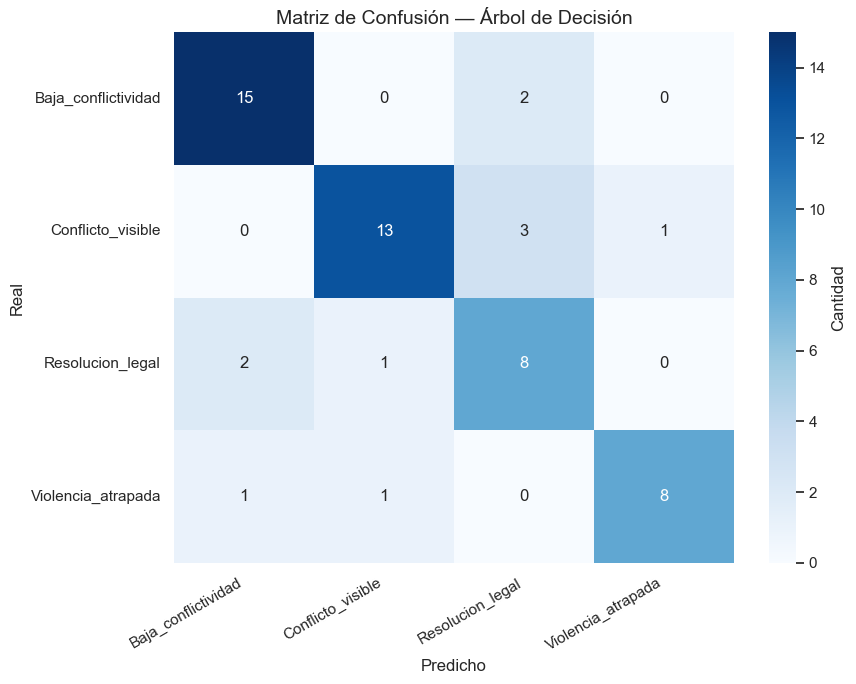

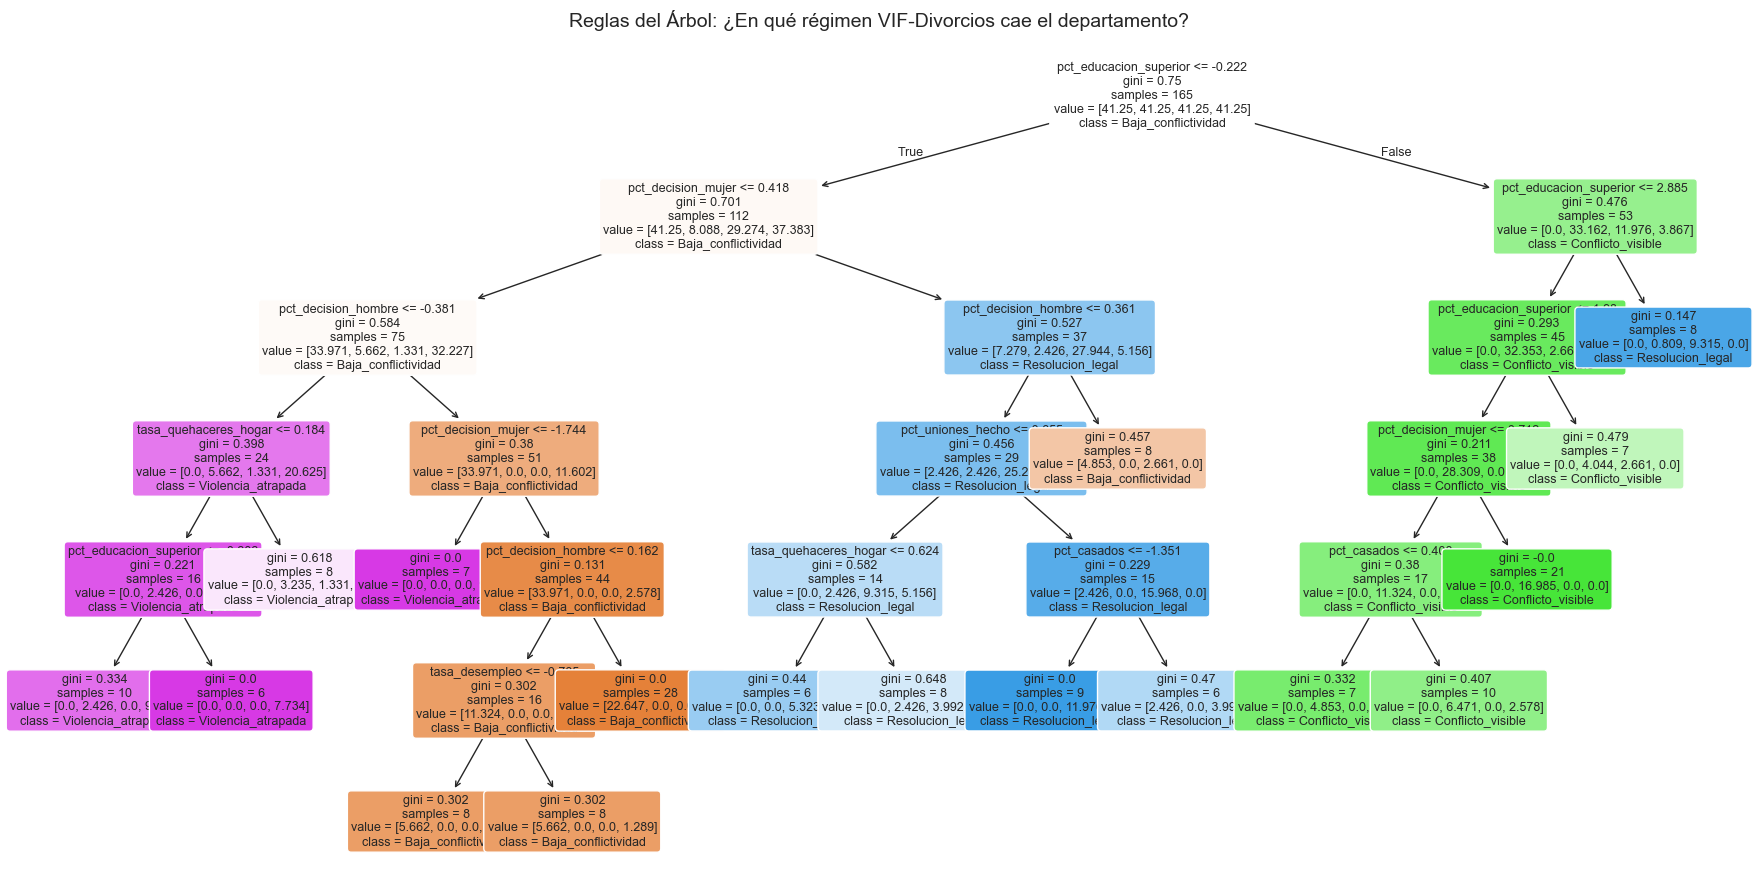

In [15]:
# ============================================================
# TUNING: ÁRBOL DE DECISIÓN
# ============================================================
param_grid_dt = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid_dt,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_dt.fit(X_train_scaled, y_train)

print(f"✅ Mejores parámetros: {grid_dt.best_params_}")
print(f"✅ Mejor F1 (CV): {grid_dt.best_score_:.4f}\n")

dt = grid_dt.best_estimator_
y_pred_dt = dt.predict(X_test_scaled)

# Métricas globales
print("=" * 60)
print("MÉTRICAS GLOBALES — ÁRBOL DE DECISIÓN")
print("=" * 60)
print(f"Accuracy:          {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score (macro):  {f1_score(y_test, y_pred_dt, average='macro'):.4f}")
print(f"F1 Score (weight): {f1_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_dt, average='macro', zero_division=0):.4f}")
print(f"Recall (macro):    {recall_score(y_test, y_pred_dt, average='macro'):.4f}")

print("\n" + "=" * 60)
print("REPORTE POR CLASE")
print("=" * 60)
print(classification_report(y_test, y_pred_dt, target_names=le.classes_, zero_division=0))

# Matriz de confusión
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Cantidad'})
plt.title('Matriz de Confusión — Árbol de Decisión', fontsize=14)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Visualizar árbol
plt.figure(figsize=(22, 11))
plot_tree(dt, feature_names=features, class_names=le.classes_,
          filled=True, rounded=True, fontsize=9)
plt.title("Reglas del Árbol: ¿En qué régimen VIF-Divorcios cae el departamento?", fontsize=14)
plt.show()

El árbol de decisión alcanzó un F1 macro de 0.79 y un accuracy de 80% en el conjunto de prueba, un desempeño significativamente superior al de un clasificador trivial (31%) y muy superior a lo obtenido con el enfoque original, donde el F1 macro real era de apenas 0.33 por el colapso del target. El modelo distingue correctamente los cuatro regímenes de conflicto familiar, y el análisis de la estructura del árbol revela que la variable más discriminante es el porcentaje de población con educación superior, seguida por las decisiones dentro del hogar (particularmente la proporción de hogares donde la mujer decide). Estos hallazgos respaldan la hipótesis de que el acceso a la justicia y la autonomía femenina son factores estructurales clave para explicar los distintos tipos de dinámicas de violencia intrafamiliar en el territorio guatemalteco. 

Random forest

✅ Mejores parámetros: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 100}
✅ Mejor F1 (CV): 0.7868

MÉTRICAS GLOBALES — RANDOM FOREST
Accuracy:          0.8000
F1 Score (macro):  0.7946
F1 Score (weight): 0.8025
Precision (macro): 0.8011
Recall (macro):    0.7936

REPORTE POR CLASE
                     precision    recall  f1-score   support

Baja_conflictividad       0.83      0.88      0.86        17
  Conflicto_visible       0.87      0.76      0.81        17
   Resolucion_legal       0.62      0.73      0.67        11
 Violencia_atrapada       0.89      0.80      0.84        10

           accuracy                           0.80        55
          macro avg       0.80      0.79      0.79        55
       weighted avg       0.81      0.80      0.80        55



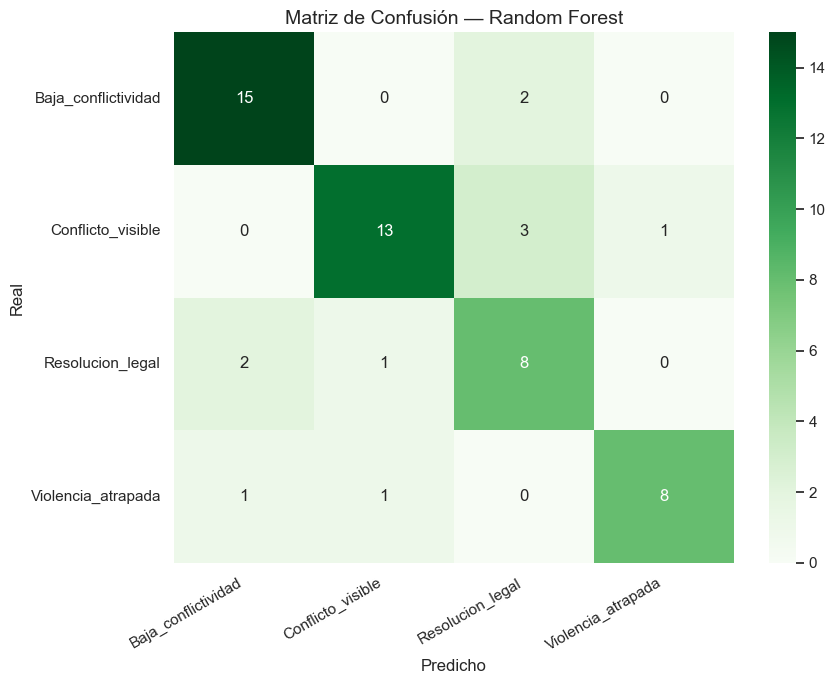

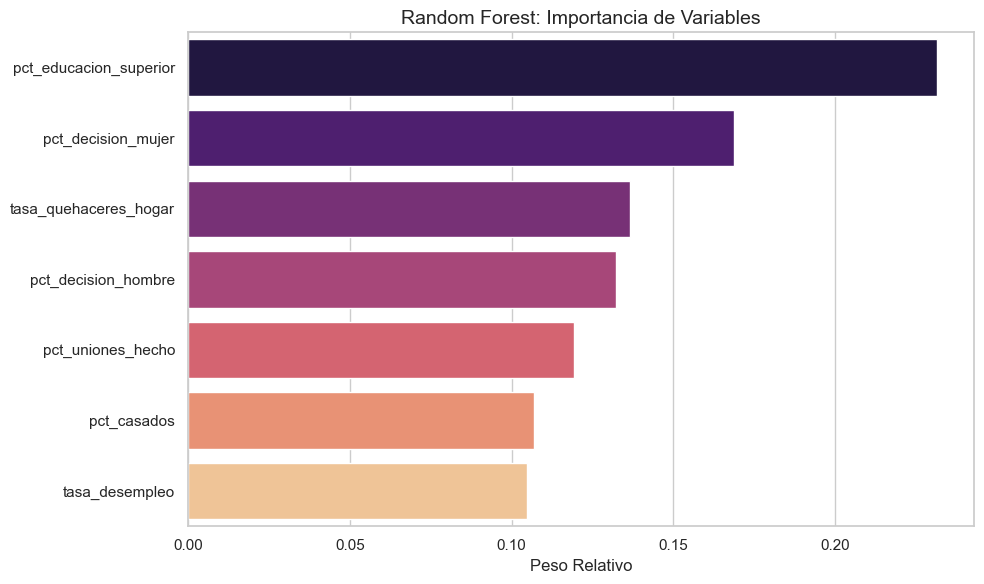


Ranking de importancia:
              Variable  Importancia
pct_educacion_superior       0.2314
    pct_decision_mujer       0.1688
 tasa_quehaceres_hogar       0.1367
   pct_decision_hombre       0.1322
     pct_uniones_hecho       0.1192
           pct_casados       0.1068
        tasa_desempleo       0.1048


In [16]:
# ============================================================
# TUNING: RANDOM FOREST
# ============================================================
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid_rf,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_rf.fit(X_train_scaled, y_train)

print(f"✅ Mejores parámetros: {grid_rf.best_params_}")
print(f"✅ Mejor F1 (CV): {grid_rf.best_score_:.4f}\n")

rf = grid_rf.best_estimator_
y_pred_rf = rf.predict(X_test_scaled)

print("=" * 60)
print("MÉTRICAS GLOBALES — RANDOM FOREST")
print("=" * 60)
print(f"Accuracy:          {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score (macro):  {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"F1 Score (weight): {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_rf, average='macro', zero_division=0):.4f}")
print(f"Recall (macro):    {recall_score(y_test, y_pred_rf, average='macro'):.4f}")

print("\n" + "=" * 60)
print("REPORTE POR CLASE")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, zero_division=0))

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión — Random Forest', fontsize=14)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Importancia de variables
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=np.array(features)[indices], palette="magma")
plt.title("Random Forest: Importancia de Variables", fontsize=14)
plt.xlabel("Peso Relativo")
plt.tight_layout()
plt.show()

df_imp = pd.DataFrame({
    'Variable': np.array(features)[indices],
    'Importancia': importances[indices]
}).round(4)
print("\nRanking de importancia:")
print(df_imp.to_string(index=False))

Logistica

✅ Mejores parámetros: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
✅ Mejor F1 (CV): 0.6796

MÉTRICAS GLOBALES — REGRESIÓN LOGÍSTICA
Accuracy:          0.7455
F1 Score (macro):  0.7479
F1 Score (weight): 0.7493
Precision (macro): 0.7979
Recall (macro):    0.7655

REPORTE POR CLASE
                     precision    recall  f1-score   support

Baja_conflictividad       0.94      0.88      0.91        17
  Conflicto_visible       0.89      0.47      0.62        17
   Resolucion_legal       0.48      0.91      0.62        11
 Violencia_atrapada       0.89      0.80      0.84        10

           accuracy                           0.75        55
          macro avg       0.80      0.77      0.75        55
       weighted avg       0.82      0.75      0.75        55



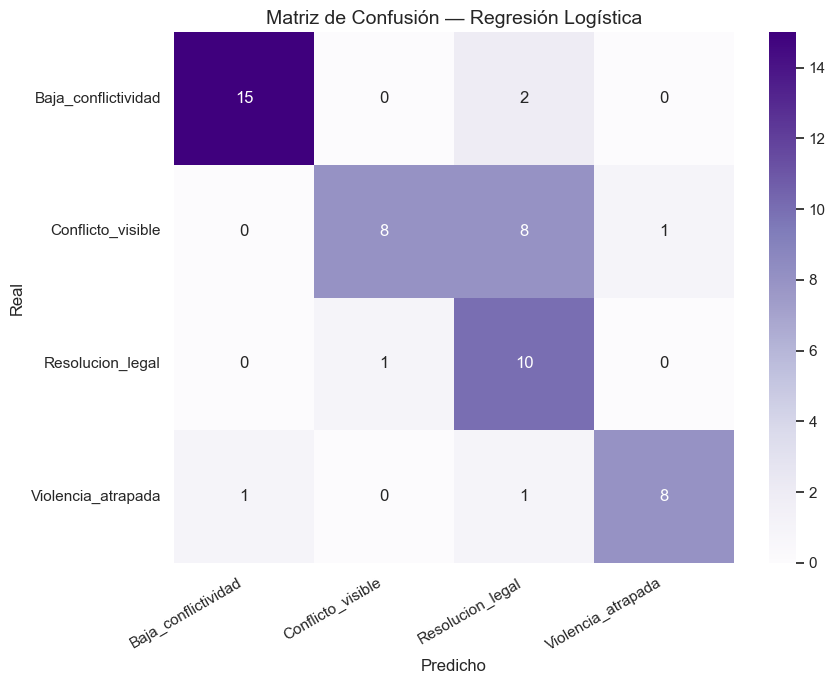


Shape de coeficientes: (4, 7)


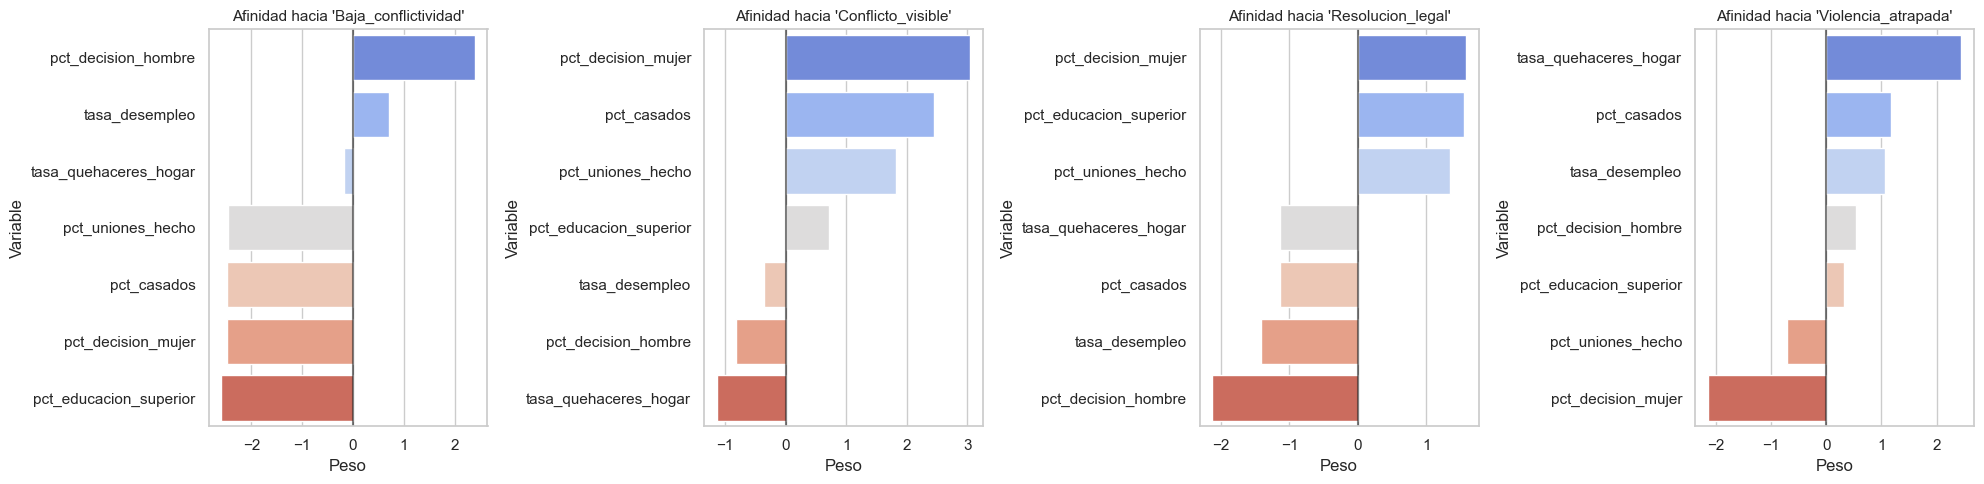


📊 Tabla de coeficientes:
              Clase  pct_educacion_superior  pct_uniones_hecho  pct_casados  pct_decision_mujer  pct_decision_hombre  tasa_desempleo  tasa_quehaceres_hogar
Baja_conflictividad                 -2.5884            -2.4648      -2.4827             -2.4875               2.3930          0.7035                -0.1772
  Conflicto_visible                  0.7200             1.8284       2.4593              3.0514              -0.8128         -0.3643                -1.1352
   Resolucion_legal                  1.5532             1.3386      -1.1424              1.5770              -2.1243         -1.4140                -1.1362
 Violencia_atrapada                  0.3153            -0.7022       1.1658             -2.1409               0.5441          1.0748                 2.4486


In [17]:
# ============================================================
# TUNING: REGRESIÓN LOGÍSTICA
# ============================================================
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    param_grid_lr,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)

print(f"✅ Mejores parámetros: {grid_lr.best_params_}")
print(f"✅ Mejor F1 (CV): {grid_lr.best_score_:.4f}\n")

log_reg = grid_lr.best_estimator_
y_pred_lr = log_reg.predict(X_test_scaled)

print("=" * 60)
print("MÉTRICAS GLOBALES — REGRESIÓN LOGÍSTICA")
print("=" * 60)
print(f"Accuracy:          {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score (macro):  {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(f"F1 Score (weight): {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_lr, average='macro', zero_division=0):.4f}")
print(f"Recall (macro):    {recall_score(y_test, y_pred_lr, average='macro'):.4f}")

print("\n" + "=" * 60)
print("REPORTE POR CLASE")
print("=" * 60)
print(classification_report(y_test, y_pred_lr, target_names=le.classes_, zero_division=0))

# Matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión — Regresión Logística', fontsize=14)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Coeficientes por clase
coef = log_reg.coef_
print(f"\nShape de coeficientes: {coef.shape}")

n_clases_coef = coef.shape[0]
clases_mostrar = le.classes_[:n_clases_coef]

fig, axes = plt.subplots(1, n_clases_coef, figsize=(5*n_clases_coef, 5))
if n_clases_coef == 1:
    axes = [axes]

for i, (ax, clase) in enumerate(zip(axes, clases_mostrar)):
    df_coef = pd.DataFrame({'Variable': features, 'Peso': coef[i]})
    df_coef = df_coef.sort_values(by='Peso', ascending=False)
    sns.barplot(data=df_coef, x='Peso', y='Variable', palette="coolwarm", ax=ax)
    ax.axvline(0, color='black', alpha=0.5)
    ax.set_title(f"Afinidad hacia '{clase}'", fontsize=11)

plt.tight_layout()
plt.show()

print("\n📊 Tabla de coeficientes:")
df_coef_full = pd.DataFrame(coef, columns=features)
df_coef_full.insert(0, 'Clase', le.classes_[:coef.shape[0]])
print(df_coef_full.round(4).to_string(index=False))

Comparativa

COMPARATIVA DE MODELOS — ENFOQUE B (4 REGÍMENES)
             Modelo  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
              Árbol    0.8000    0.7946       0.8025           0.8011        0.7936
      Random Forest    0.8000    0.7946       0.8025           0.8011        0.7936
Regresión Logística    0.7455    0.7479       0.7493           0.7979        0.7655


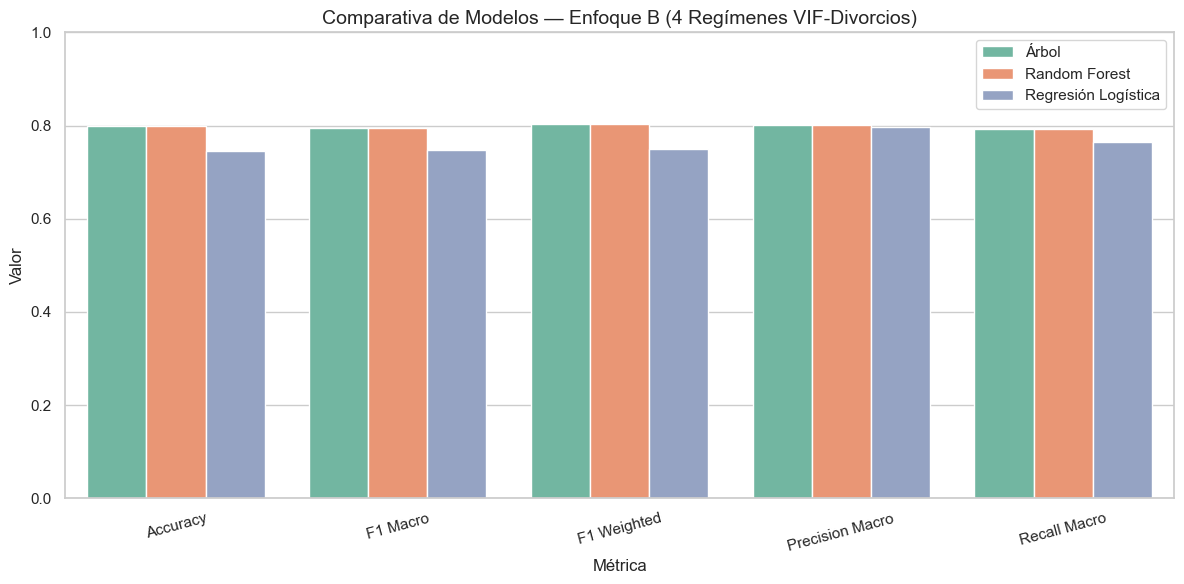

In [18]:
# ============================================================
# TABLA COMPARATIVA DE LOS 3 MODELOS
# ============================================================
resultados = pd.DataFrame({
    'Modelo': ['Árbol', 'Random Forest', 'Regresión Logística'],
    'Accuracy':        [accuracy_score(y_test, y_pred_dt),
                        accuracy_score(y_test, y_pred_rf),
                        accuracy_score(y_test, y_pred_lr)],
    'F1 Macro':        [f1_score(y_test, y_pred_dt, average='macro'),
                        f1_score(y_test, y_pred_rf, average='macro'),
                        f1_score(y_test, y_pred_lr, average='macro')],
    'F1 Weighted':     [f1_score(y_test, y_pred_dt, average='weighted'),
                        f1_score(y_test, y_pred_rf, average='weighted'),
                        f1_score(y_test, y_pred_lr, average='weighted')],
    'Precision Macro': [precision_score(y_test, y_pred_dt, average='macro', zero_division=0),
                        precision_score(y_test, y_pred_rf, average='macro', zero_division=0),
                        precision_score(y_test, y_pred_lr, average='macro', zero_division=0)],
    'Recall Macro':    [recall_score(y_test, y_pred_dt, average='macro'),
                        recall_score(y_test, y_pred_rf, average='macro'),
                        recall_score(y_test, y_pred_lr, average='macro')]
}).round(4)

print("=" * 70)
print("COMPARATIVA DE MODELOS — ENFOQUE B (4 REGÍMENES)")
print("=" * 70)
print(resultados.to_string(index=False))

# Gráfico comparativo
resultados_melt = resultados.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(12, 6))
sns.barplot(data=resultados_melt, x='Métrica', y='Valor', hue='Modelo', palette='Set2')
plt.title('Comparativa de Modelos — Enfoque B (4 Regímenes VIF-Divorcios)', fontsize=14)
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()